# Third Week Assignment — Makemore

Bu defter karakter seviyesinde isim üreten modelleri adım adım kurar:

1. İngilizce isimlerde bigram sayımı (dictionary ve tensor)
2. Sayım tablosundan olasılık ve örnekleme
3. Negative log likelihood (NLL) ve smoothing
4. Aynı bigram modelinin tek katmanlı sinir ağı karşılığı
5. Türkçe isimler ve genişletilmiş alfabe
6. Ek: train/dev/test, dev loss ile smoothing seçimi ve trigram karşılaştırması

Kaynaklar: [Karpathy makemore](https://github.com/karpathy/makemore),
[PyTorch broadcasting](https://pytorch.org/docs/stable/notes/broadcasting.html),
[Türkçe isim listesi](https://github.com/niyazikemer/turkce_isimler).

> Sabit random seed kullanıldığı için bu defter tekrar çalıştırıldığında aynı örnekleri üretir.

In [1]:
from pathlib import Path
from urllib.request import urlopen
import csv
import io
import random
import unicodedata

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F

torch.manual_seed(42)
print("PyTorch:", torch.__version__)

PyTorch: 2.11.0


## 1. Bigram'ları sayma

Bir **bigram**, art arda gelen iki karakterdir. `.` karakterini hem başlangıç hem bitiş
işareti olarak kullanıyorum. Önce Python dictionary, sonra 27×27 tensor ile aynı
sayımları oluşturuyorum.

In [2]:
data_path = Path("names.txt")
if not data_path.exists():
    # Colab'da veya repo kökünden çalıştırılırsa defterin klasörünü de dene.
    data_path = Path("third week assignment/names.txt")

words = [w.strip().lower() for w in data_path.read_text(encoding="utf-8").splitlines() if w.strip()]

print("İsim sayısı:", len(words))
print("İlk 10 isim:", words[:10])
print("En kısa / en uzun:", min(map(len, words)), "/", max(map(len, words)))

İsim sayısı: 32033
İlk 10 isim: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
En kısa / en uzun: 2 / 15


In [3]:
# Python dictionary ile bigram sayımı
b = {}
for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

sorted(b.items(), key=lambda kv: -kv[1])[:10]

[(('n', '.'), 6763),
 (('a', '.'), 6640),
 (('a', 'n'), 5438),
 (('.', 'a'), 4410),
 (('e', '.'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('.', 'k'), 2963)]

In [4]:
# Tensor ile aynı sayım: 26 harf + başlangıç/bitiş işareti = 27
chars = sorted(set("".join(words)))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}

V = len(stoi)
assert V == 27, f"İngilizce vocabulary 27 olmalı, gelen: {V}"

N = torch.zeros((V, V), dtype=torch.int32)
for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        N[stoi[ch1], stoi[ch2]] += 1

# Dictionary ile tensor tamamen aynı şeyi saymalı.
assert all(N[stoi[a], stoi[z]].item() == count for (a, z), count in b.items())
print("Tensor boyutu:", tuple(N.shape), "| Toplam bigram:", N.sum().item())

Tensor boyutu: (27, 27) | Toplam bigram: 228146


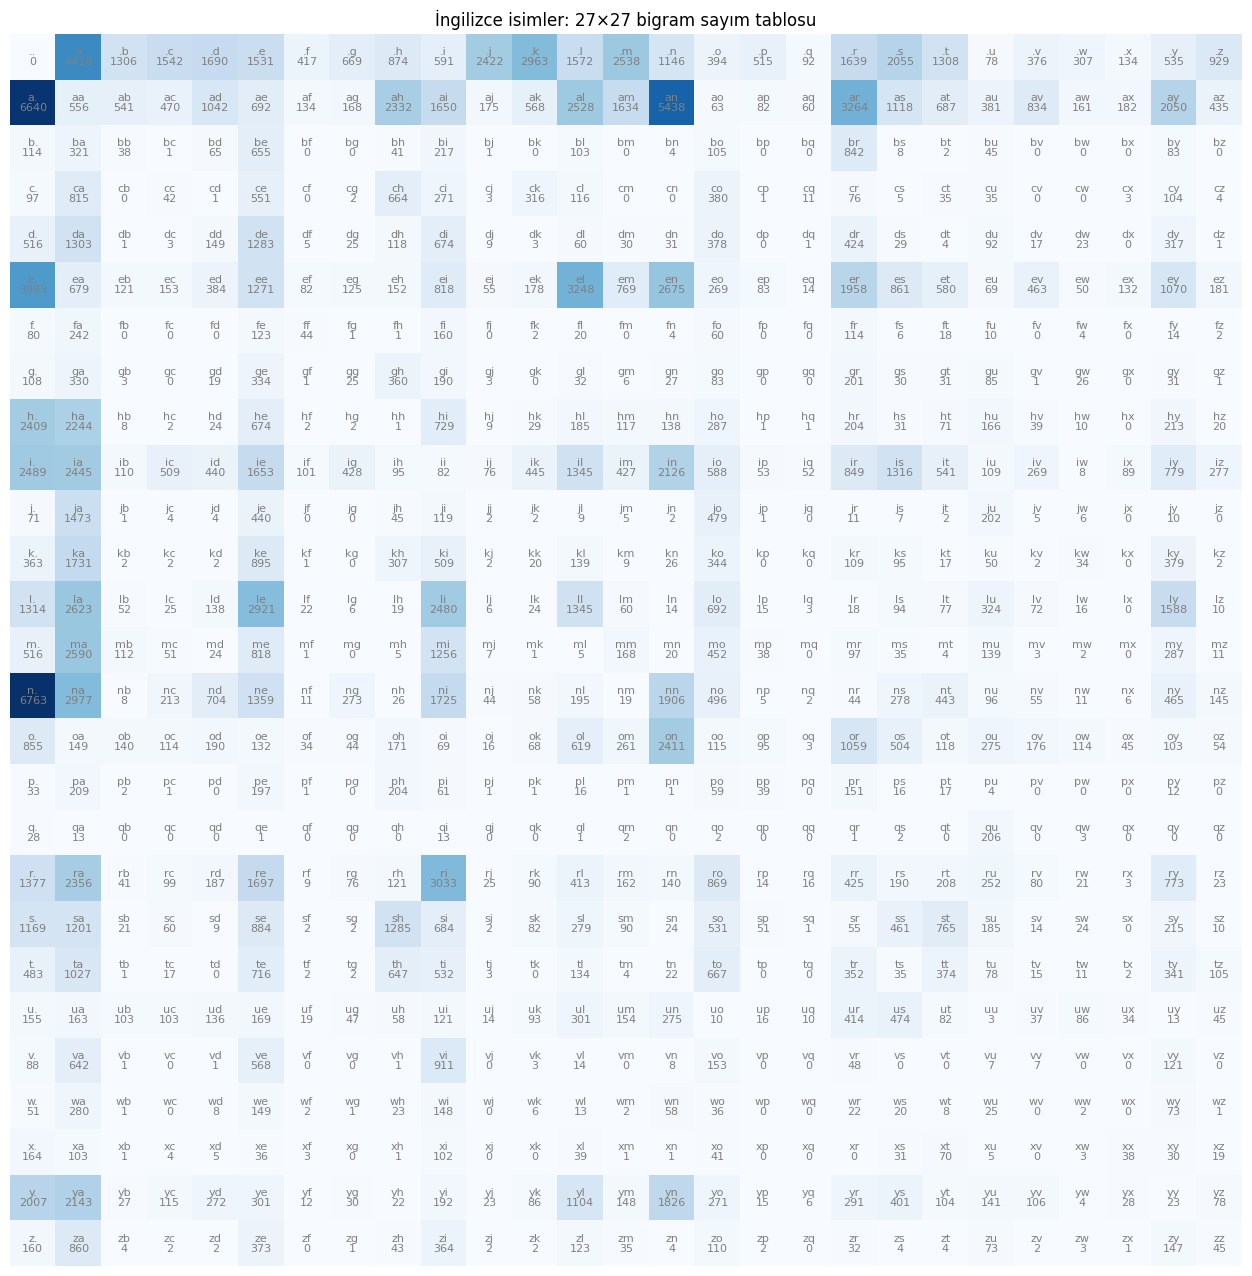

In [5]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap="Blues")
for i in range(V):
    for j in range(V):
        plt.text(j, i, itos[i] + itos[j], ha="center", va="bottom", color="gray", fontsize=8)
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray", fontsize=8)
plt.axis("off")
plt.title("İngilizce isimler: 27×27 bigram sayım tablosu")
plt.show()

## 2. Satırları olasılığa çevirme ve örnekleme

Her satır, mevcut karakterden sonra hangi karakterin gelebileceğini gösterir. Bu yüzden
her satırı **kendi toplamına** bölmeliyiz. `keepdim=True`, toplamı `(27, 1)` biçiminde
tutar; böylece broadcasting her satırı kendi tek sayısına böler. `keepdim=False` ile
çıkan `(27,)` vektörü sessizce sütunlara hizalanır ve yanlış bir model üretir.

In [6]:
alpha = 1.0  # görev 3'te açıklanan sahte sayım
counts = N.float() + alpha
row_totals = counts.sum(dim=1, keepdim=True)  # (27, 1)
P = counts / row_totals                       # (27, 27) / (27, 1)

# Sessiz broadcasting tuzağını görünür kılalım.
P_wrong = counts / counts.sum(dim=1)          # (27, 27) / (27,) -> sütunlara hizalanır

print("Doğru satır toplamları:", P.sum(dim=1)[:5])
print("Yanlış satır toplamları:", P_wrong.sum(dim=1)[:5])
assert torch.allclose(P.sum(dim=1), torch.ones(V), atol=1e-6)
assert not torch.allclose(P_wrong.sum(dim=1), torch.ones(V), atol=1e-3)

Doğru satır toplamları: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
Yanlış satır toplamları: tensor([6.9246, 4.3671, 0.2122, 0.3786, 0.4241])


In [7]:
def sample_bigram(P, itos, n=20, seed=2147483647, max_length=30):
    g = torch.Generator().manual_seed(seed)
    samples = []
    for _ in range(n):
        out = []
        ix = 0
        for _ in range(max_length):
            ix = torch.multinomial(P[ix], num_samples=1, replacement=True, generator=g).item()
            if ix == 0:
                break
            out.append(itos[ix])
        samples.append("".join(out))
    return samples

print(*sample_bigram(P, itos), sep="\n")

cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda
ka
emimmsade
enkaviyny
ftlspihinivenvorhlasu
dsor
br
jol
pen
aisan
ja


## 3. Negative log likelihood ve smoothing

- **Neden log?** Bir ismin olasılığı çok sayıda küçük olasılığın çarpımıdır. Log,
  çarpımları toplama çevirir ve çok küçük sayılarla çalışmayı daha kararlı yapar.
- **Neden negatif?** Doğru karaktere verilen olasılık 0–1 aralığında olduğundan log
  değeri sıfır veya negatiftir. Eksi işareti, daha iyi tahminin daha küçük bir loss
  üretmesini sağlar; böylece loss'u minimize edebiliriz.
- **Neden ortalama?** Toplam loss veri büyüklüğüyle artar. Örnek başına ortalama,
  farklı veri bölümlerini ve modelleri adil biçimde karşılaştırır.
- **Neden smoothing?** Görülmemiş bir bigramın sayımı 0 ise olasılığı da 0, `log(0)`
  ise sonsuz olur. Her hücreye sahte sayım (`alpha`) eklemek bunu engeller.

In [8]:
def bigram_nll(words, P, stoi):
    log_likelihood = 0.0
    n = 0
    for w in words:
        chs = ["."] + list(w) + ["."]
        for ch1, ch2 in zip(chs, chs[1:]):
            prob = P[stoi[ch1], stoi[ch2]]
            log_likelihood += torch.log(prob).item()
            n += 1
    return -log_likelihood / n

count_loss_en = bigram_nll(words, P, stoi)
print(f"İngilizce sayım modeli NLL (alpha={alpha:g}): {count_loss_en:.6f}")

İngilizce sayım modeli NLL (alpha=1): 2.454577


## 4. Aynı bigram modeli: tek katmanlı sinir ağı

Her giriş karakterini one-hot vektöre çeviriyorum. `27×27` ağırlık matrisi bir sonraki
karakter için 27 logit üretir. Softmax bu logitleri olasılığa, NLL ise loss'a çevirir.
`backward()` ile hesaplanan gradient, geçen haftaki micrograd'da elle kurduğumuz
zincir kuralının PyTorch karşılığıdır.

In [9]:
def build_bigram_dataset(words, stoi):
    xs, ys = [], []
    for w in words:
        chs = ["."] + list(w) + ["."]
        for ch1, ch2 in zip(chs, chs[1:]):
            xs.append(stoi[ch1])
            ys.append(stoi[ch2])
    return torch.tensor(xs), torch.tensor(ys)


def train_one_layer_nn(words, stoi, steps=200, learning_rate=50.0, reg=0.01, seed=42):
    xs, ys = build_bigram_dataset(words, stoi)
    vocab_size = len(stoi)
    xenc = F.one_hot(xs, num_classes=vocab_size).float()
    g = torch.Generator().manual_seed(seed)
    W = torch.randn((vocab_size, vocab_size), generator=g, requires_grad=True)
    history = []

    for step in range(steps):
        logits = xenc @ W
        exp_logits = logits.exp()
        probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)  # softmax
        data_loss = -probs[torch.arange(len(ys)), ys].log().mean()
        loss = data_loss + reg * (W**2).mean()

        W.grad = None
        loss.backward()
        W.data += -learning_rate * W.grad

        history.append(data_loss.item())
        if step % 50 == 0 or step == steps - 1:
            print(f"step {step:3d} | data NLL {data_loss.item():.6f}")

    return W, history


W_en, nn_history_en = train_one_layer_nn(words, stoi)
nn_loss_en = nn_history_en[-1]
print(f"\nSayım modeli : {count_loss_en:.6f}")
print(f"Sinir ağı    : {nn_loss_en:.6f}")
print(f"Mutlak fark  : {abs(nn_loss_en - count_loss_en):.6f}")

step   0 | data NLL 3.696648


step  50 | data NLL 2.496775


step 100 | data NLL 2.474905


step 150 | data NLL 2.468352


step 199 | data NLL 2.465406

Sayım modeli : 2.454577
Sinir ağı    : 2.465406
Mutlak fark  : 0.010829


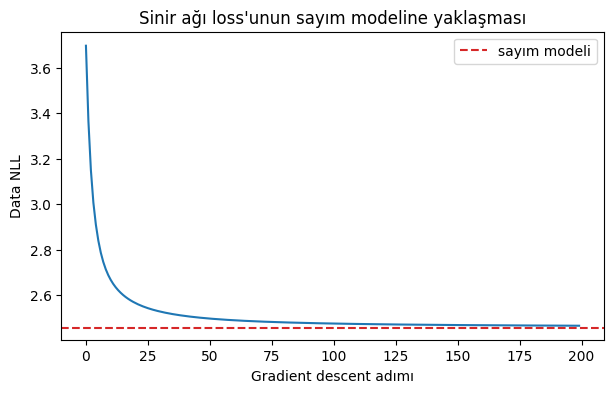

Sinir ağından örnekler:
kyason
kanana
milaveela
ra
drisan
lurtolisyrsh
tobay
n
myeeahare
chucinailelulelone


In [10]:
with torch.no_grad():
    P_nn_en = W_en.softmax(dim=1)

plt.figure(figsize=(7, 4))
plt.plot(nn_history_en)
plt.axhline(count_loss_en, color="tab:red", linestyle="--", label="sayım modeli")
plt.xlabel("Gradient descent adımı")
plt.ylabel("Data NLL")
plt.title("Sinir ağı loss'unun sayım modeline yaklaşması")
plt.legend()
plt.show()

print("Sinir ağından örnekler:")
print(*sample_bigram(P_nn_en, itos, n=10, seed=1234), sep="\n")

## 5. Türkçe isim listesiyle iki modeli tekrar çalıştırma

Kaynak listedeki isimleri Unicode NFC biçimine getirip küçük harfe çeviriyorum.
Vocabulary'yi İngilizce harflere `ç, ğ, ı, ö, ş, ü` ekleyerek genişletiyorum.
Kaynakta geçen az sayıdaki `w` ve `x` harfi de genişletilmiş Latin kümesinde kalıyor.

In [11]:
TURKISH_DATA_URL = "https://raw.githubusercontent.com/niyazikemer/turkce_isimler/main/turkce_isim.csv"
raw_csv = urlopen(TURKISH_DATA_URL).read().decode("utf-8-sig")
rows = csv.DictReader(io.StringIO(raw_csv))

turkish_words = []
for row in rows:
    name = unicodedata.normalize("NFC", row["name"].strip().lower())
    if name and name.isalpha():
        turkish_words.append(name)
turkish_words = sorted(set(turkish_words))

alphabet_tr = list("abcdefghijklmnopqrstuvwxyzçğıöşü")
assert all(ch in alphabet_tr for w in turkish_words for ch in w)
assert all(ch in "".join(turkish_words) for ch in "çğıöşü")

stoi_tr = {".": 0, **{ch: i + 1 for i, ch in enumerate(alphabet_tr)}}
itos_tr = {i: ch for ch, i in stoi_tr.items()}
V_tr = len(stoi_tr)

print("Tekil Türkçe isim sayısı:", len(turkish_words))
print("Vocabulary boyutu:", V_tr)
print("Eklenen Türkçe karakterler:", list("çğıöşü"))
print("İlk 10 isim:", turkish_words[:10])

Tekil Türkçe isim sayısı: 13872
Vocabulary boyutu: 33
Eklenen Türkçe karakterler: ['ç', 'ğ', 'ı', 'ö', 'ş', 'ü']
İlk 10 isim: ['aba', 'abaca', 'abacan', 'abay', 'abayhan', 'abaza', 'abaç', 'abbas', 'abdal', 'abdi']


In [12]:
def count_bigrams(words, stoi):
    N = torch.zeros((len(stoi), len(stoi)), dtype=torch.int64)
    for w in words:
        chs = ["."] + list(w) + ["."]
        for ch1, ch2 in zip(chs, chs[1:]):
            N[stoi[ch1], stoi[ch2]] += 1
    return N


N_tr = count_bigrams(turkish_words, stoi_tr)
P_tr = (N_tr.float() + 1.0)
P_tr /= P_tr.sum(dim=1, keepdim=True)
count_loss_tr = bigram_nll(turkish_words, P_tr, stoi_tr)

print(f"Türkçe sayım modeli NLL: {count_loss_tr:.6f}")
print("\nTürkçe sayım modelinden örnekler:")
print(*sample_bigram(P_tr, itos_tr, n=15, seed=2026), sep="\n")

Türkçe sayım modeli NLL: 2.500852

Türkçe sayım modelinden örnekler:
sategeza
bey
alpenyurşefakevir
mibutal
atyalbihik
yene
in
guliz
a
ms
fenurmstuhan
nal
st
n
bepanahen


In [13]:
W_tr, nn_history_tr = train_one_layer_nn(
    turkish_words, stoi_tr, steps=200, learning_rate=50.0, reg=0.01, seed=2026
)
nn_loss_tr = nn_history_tr[-1]

print(f"\nTürkçe sayım modeli : {count_loss_tr:.6f}")
print(f"Türkçe sinir ağı    : {nn_loss_tr:.6f}")
print(f"Mutlak fark          : {abs(nn_loss_tr - count_loss_tr):.6f}")

with torch.no_grad():
    P_nn_tr = W_tr.softmax(dim=1)
print("\nTürkçe sinir ağından örnekler:")
print(*sample_bigram(P_nn_tr, itos_tr, n=15, seed=2027), sep="\n")

step   0 | data NLL 4.048819


step  50 | data NLL 2.563593


step 100 | data NLL 2.530131


step 150 | data NLL 2.520411


step 199 | data NLL 2.515891

Türkçe sayım modeli : 2.500852
Türkçe sinir ağı    : 2.515891
Mutlak fark          : 0.015039

Türkçe sinir ağından örnekler:
mivideözfabey
anıl
ban
cel
bat
mdimülrsudehale
bek
eraze

gülatakaran
yapababer
dilil
tedar
ariybemse
bem


## 6. Ek: trigram, train/dev/test ve smoothing seçimi

İsimleri sabit seed ile %80 train, %10 dev ve %10 test olarak ayırıyorum. Smoothing
gücünü **yalnızca dev loss** ile seçiyor, son karşılaştırmayı test bölümünde yapıyorum.
Trigram modeli bir sonraki harfi tahmin ederken son iki karakteri bağlam olarak kullanır.

In [14]:
rng = random.Random(42)
split_words = turkish_words.copy()
rng.shuffle(split_words)
n1 = int(0.8 * len(split_words))
n2 = int(0.9 * len(split_words))
train_words = split_words[:n1]
dev_words = split_words[n1:n2]
test_words = split_words[n2:]

print("train / dev / test:", len(train_words), len(dev_words), len(test_words))

train / dev / test: 11097 1387 1388


In [15]:
def count_ngram(words, stoi, order):
    V = len(stoi)
    rows = V if order == 2 else V * V
    C = torch.zeros((rows, V), dtype=torch.int64)

    for w in words:
        padded = ["."] * (order - 1) + list(w) + ["."]
        for i in range(len(padded) - order + 1):
            context = padded[i:i + order - 1]
            target = padded[i + order - 1]
            if order == 2:
                row = stoi[context[0]]
            else:
                row = stoi[context[0]] * V + stoi[context[1]]
            C[row, stoi[target]] += 1
    return C


def probabilities(C, alpha):
    P = C.float() + alpha
    return P / P.sum(dim=1, keepdim=True)


def ngram_nll(words, P, stoi, order):
    V = len(stoi)
    total = 0.0
    n = 0
    for w in words:
        padded = ["."] * (order - 1) + list(w) + ["."]
        for i in range(len(padded) - order + 1):
            context = padded[i:i + order - 1]
            target = stoi[padded[i + order - 1]]
            row = stoi[context[0]] if order == 2 else stoi[context[0]] * V + stoi[context[1]]
            total += -torch.log(P[row, target]).item()
            n += 1
    return total / n


def tune_alpha(train_words, dev_words, stoi, order, candidates):
    C = count_ngram(train_words, stoi, order)
    rows = []
    for alpha in candidates:
        P = probabilities(C, alpha)
        rows.append({"order": order, "alpha": alpha, "dev_nll": ngram_nll(dev_words, P, stoi, order)})
    best = min(rows, key=lambda row: row["dev_nll"])
    return C, rows, best


alphas = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
C2, rows2, best2 = tune_alpha(train_words, dev_words, stoi_tr, 2, alphas)
C3, rows3, best3 = tune_alpha(train_words, dev_words, stoi_tr, 3, alphas)

results = pd.DataFrame(rows2 + rows3)
results.pivot(index="alpha", columns="order", values="dev_nll").rename(columns={2: "bigram", 3: "trigram"})

order,bigram,trigram
alpha,,
0.01,2.497354,2.251036
0.03,2.496309,2.234292
0.10,2.495306,2.224045
0.30,2.494817,2.231587
1.00,2.495978,2.277743
3.00,2.502535,2.379024
10.00,2.530103,2.577491


In [16]:
P2_best = probabilities(C2, best2["alpha"])
P3_best = probabilities(C3, best3["alpha"])

bigram_test_loss = ngram_nll(test_words, P2_best, stoi_tr, 2)
trigram_test_loss = ngram_nll(test_words, P3_best, stoi_tr, 3)

comparison = pd.DataFrame([
    {"model": "bigram", "best_alpha": best2["alpha"], "dev_nll": best2["dev_nll"], "test_nll": bigram_test_loss},
    {"model": "trigram", "best_alpha": best3["alpha"], "dev_nll": best3["dev_nll"], "test_nll": trigram_test_loss},
])
comparison

,model,best_alpha,dev_nll,test_nll
0,bigram,0.3,2.494817,2.508207
1,trigram,0.1,2.224045,2.250430


In [17]:
def sample_ngram(P, itos, order, n=15, seed=42, max_length=30):
    V = len(itos)
    g = torch.Generator().manual_seed(seed)
    samples = []
    for _ in range(n):
        context = [0] * (order - 1)
        out = []
        for _ in range(max_length):
            row = context[0] if order == 2 else context[0] * V + context[1]
            ix = torch.multinomial(P[row], 1, replacement=True, generator=g).item()
            if ix == 0:
                break
            out.append(itos[ix])
            context = (context + [ix])[-(order - 1):]
        samples.append("".join(out))
    return samples


samples = pd.DataFrame({
    "bigram": sample_ngram(P2_best, itos_tr, order=2, seed=99),
    "trigram": sample_ngram(P3_best, itos_tr, order=3, seed=99),
})
samples

,bigram,trigram
0,me,me
1,azorzeşifun,asorge
2,ılal,nüstayılayçendariymeranadal
3,çenelin,beyi
4,meranadal,bar
5,besi,bey
6,bar,orayye
7,bere,müribahniz
8,aldırülürilücaye,surbay
9,surbayarafamil,raffuxlüfe


### Sonuç

Trigram, iki karakterlik bağlam sayesinde Türkçedeki hece ve harf dizilerini bigramdan
daha iyi yakalar; bu yüzden test NLL'sinin düşmesi beklenir. Örneklerde de trigram
çıktıları genellikle daha tutarlı heceler taşır. Buna karşılık trigram tablosu daha
büyüktür ve seyrek bağlamlar yüzünden smoothing seçimine daha duyarlıdır.

Üretilen diziler model örneğidir; gerçek kişi adı olmak zorunda değildir.